# Homework 2
## Анализ текста, текстовые модели


### Часть 2: Классификация тональности с помощью BERT

Задача:

Цель этой задачи — использовать предварительно обученную модель BERT для классификации тональности рецензий на фильмы.

[IMDB Dataset](https://disk.yandex.ru/d/dhKpEgM4rQkLiQ)

#### **Задание для части 2:**

Используйте предварительно обученную модель BERT для классификации тональности отзывов о фильмах. (Вес задания: 20%)

### Prepare yourself, samurai...

> Установку и подготовку пакетов, аналогично первому блокноту, я решил выделить в отдельный блок; помимо прочего, здесь присутствует цеплялка к хранилищу google drive для взаимодействия с весами: экспорта и импорта после обучения соответственно.

> Обучал на бесплатной T4 в colab.

In [ ]:
#!pip install pandas numpy torch torchaudio torchvision transformers tqdm scikit-learn gdown

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import BertModel, BertPreTrainedModel, BertConfig
from transformers import BertForSequenceClassification, BertTokenizerFast

from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_recall_fscore_support, f1_score,
                             roc_auc_score, accuracy_score, roc_curve,
                             classification_report, confusion_matrix,
                             precision_score, recall_score)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import warnings
import gdown
import os
import re

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"current device: {device}")


current device: cuda


### Ok, but why?..

> Подготовка данных перед обучением происходит довольно занятным образом; признаться, мне было лень подключать хранилку gdrive, чтобы работать с датасетом напрямую, и я, поначалу, в целях экономии времени при постоянном сбросе среды, решил выкинуть этот датасет в интернет с гугл диска и скачивать его в локальную рабочую область, бессовестно используя все преимущества интернета в google. Способ, разумеется, не самый эффективный, и проще было бы через mount, но для разнообразия опыта использования я решил оставить эту ячейку.

In [ ]:
# download csv if there is not;

if not os.path.exists('IMDB.csv'):
    url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vT6-n57dcXO2nHTwmAkZSw_MGYGSd5vFIE0TtrnmePnzM37Jev_0mpXdVbLZqVLcnAYkyBpkztKpQH2/pub?output=csv'
    gdown.download(url, 'IMDB.csv', quiet=False)


Downloading...
From: https://docs.google.com/spreadsheets/d/e/2PACX-1vT6-n57dcXO2nHTwmAkZSw_MGYGSd5vFIE0TtrnmePnzM37Jev_0mpXdVbLZqVLcnAYkyBpkztKpQH2/pub?output=csv
To: /content/IMDB.csv
66.3MB [00:12, 5.31MB/s]


### Mr. Proper?..

> Поскольку BERT обучен на текстовом корпусе без приведения к "нормальному" виду и является контекстуальной моделью, излишняя предобработка может испортить качество. В связи с этим я решил сделать щадящую очистку входных данных от служебных символов, HTML-тегов, а также точек и множества пробелов.

> Дальнейшая подготовка данных основывается на загружаемом из локальной области csv; перед тем, как использовать токенизатор (который у BERT работает, опираясь на – subwords – части слов), предстоит провести небольшой анализ.

In [ ]:
def clean(text):
    if not isinstance(text, str):
        return ""
    # html-tags
    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)

    # words with dots
    text = re.sub(r'\.([A-Za-z])', r'. \1', text)
    text = re.sub(r'\!([A-Za-z])', r'! \1', text)
    text = re.sub(r'\?([A-Za-z])', r'? \1', text)

    # many spaces
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # unicode anomaly
    text = re.sub(r'[^\w\s\.\!\?\:\;\,\'\"\(\)\-\–\—]', ' ', text, flags=re.UNICODE)

    return text


In [ ]:
# loading data; splitting

imdb_raw = pd.read_csv('IMDB.csv')
texts = imdb_raw['review'].apply(clean)
clean_texts = texts.values
labels = imdb_raw['sentiment'].map({'negative': 0, 'positive': 1}).values


### Length is not the most important thing....

> Поскольку отзывы разные по длине и качеству (а еще был собран во времена, когда, скорее всего, было принято писать отзывы в интернете руками, а не ботнетом), необходимо оценить корпус данных, прежде чем разбивать собранную информацию на токены; для повышения качества датасета полезно потребовать по ним выравнивание, и это кроет в себе потенциальную проблему: при элайнменте длинного отзыва может потеряться контекст, если обрезать его неверно, поэтому я принял решение произвести дополнительный первичный анализ и оценить, сколько от общего количества отзывов выбиваются из нормы по длине.

> Небольшой спойлер: по результатам вычислений под этот критерий попали более 5% входных данных, что составляет значимую часть датасета. Для того, чтобы сохранить эти данные, я решил обрезать слишком длинные отзывы "по умному" и оставлять не только начало или конец, а брать информацию с обоих частей так, чтобы суммарно по токенам она не превышала **max_len**. Сокращая количество теряемых данных, производится вклад в конечное качество обучения модели. Графики с результатами представлены ниже.

⚠️**WARNING**⚠️: ЭТА ЯЧЕЙКА ОТДЕЛЬНО ЗАПУСКАЕТ ТОКЕНИЗАТОР, ЧТОБЫ ОЦЕНИТЬ ДЛИНУ ОТЗЫВА ПО ЗАНИМАЕМЫМ ТОКЕНАМ; ХОТЬ ОН И ЗАЯВЛЕН КАК FAST, СЛУЧАЙНЫЙ ЕЕ ЗАПУСК ОТНИМЕТ И ВРЕМЯ И ВЫЧИСЛИТЕЛЬНЫЕ РЕСУРСЫ.

 АНАЛИЗ ДЛИНЫ ТЕКСТОВ 


Анализ на полном датасете (50000 записей)

1. СИМВОЛЫ:
   Среднее: 1309
   Медиана: 970
   Максимум: 13704
   95-й перцентиль: 3391
   99-й перцентиль: 5179

2. ТОКЕНИЗАЦИЯ BERT (bert-base-uncased):


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Токенизация: 100%|██████████| 50000/50000 [00:48<00:00, 1021.50it/s]



   Статистика по токенам (WordPiece):
   Среднее: 310
   Медиана: 231
   Максимум: 3157
   95-й перцентиль: 796
   99-й перцентиль: 1198

3. АНАЛИЗ ОБРЕЗКИ (BERT лимит = 512 токенов):
Длиннее 512 токенов: 7214 (14.4%) - БУДУТ ОБРЕЗАНЫ
Длиннее 384 токенов: 12131 (24.3%) - риск потери данных
Короче 256 токенов: 28100 (56.2%) - идеально

4. РАСПРЕДЕЛЕНИЕ ПО КВАРТИЛЯМ:
       0-й перцентиль:      5 токенов
      25-й перцентиль:    167 токенов
      50-й перцентиль:    231 токенов
      75-й перцентиль:    377 токенов
      90-й перцентиль:    609 токенов
      95-й перцентиль:    796 токенов
      99-й перцентиль:   1198 токенов
     100-й перцентиль:   3157 токенов


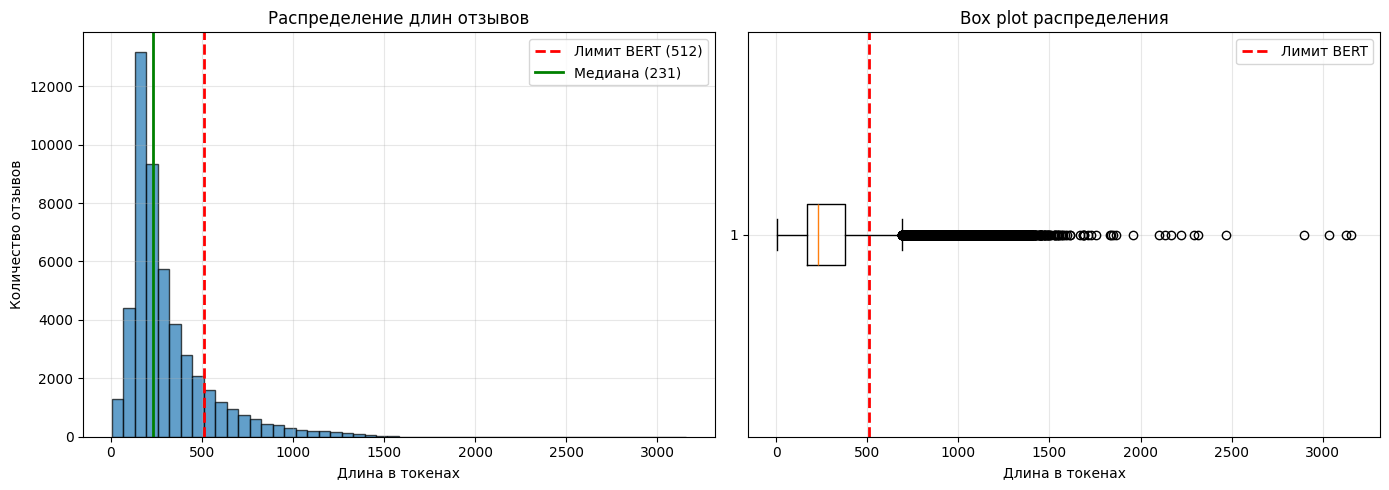

Более 5% отзывов длиннее 512 токенов!


In [ ]:
def analyze_text_lengths(df, text_column='clean_review', sample_size=None):
    print(" АНАЛИЗ ДЛИНЫ ТЕКСТОВ " + "\n" + "="*60 + '\n')


    if sample_size and len(df) > sample_size:
        df_sample = df.sample(n=sample_size, random_state=42)
        print(f"\nАнализ на выборке {sample_size} из {len(df)} записей")
    else:
        df_sample = df
        print(f"\nАнализ на полном датасете ({len(df)} записей)")

    df_sample['char_len'] = df_sample[text_column].astype(str).str.len()

    print("\n1. СИМВОЛЫ:")
    print(f"   Среднее: {df_sample['char_len'].mean():.0f}")
    print(f"   Медиана: {df_sample['char_len'].median():.0f}")
    print(f"   Максимум: {df_sample['char_len'].max()}")
    print(f"   95-й перцентиль: {df_sample['char_len'].quantile(0.95):.0f}")
    print(f"   99-й перцентиль: {df_sample['char_len'].quantile(0.99):.0f}")

    print("\n2. ТОКЕНИЗАЦИЯ BERT (bert-base-uncased):")

    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

    def count_tokens(text):
        return len(tokenizer.encode(text, truncation=False))

    from tqdm import tqdm
    tqdm.pandas(desc="Токенизация")
    df_sample['token_len'] = df_sample[text_column].progress_apply(count_tokens)

    print(f"\n   Статистика по токенам (WordPiece):")
    print(f"   Среднее: {df_sample['token_len'].mean():.0f}")
    print(f"   Медиана: {df_sample['token_len'].median():.0f}")
    print(f"   Максимум: {df_sample['token_len'].max()}")
    print(f"   95-й перцентиль: {df_sample['token_len'].quantile(0.95):.0f}")
    print(f"   99-й перцентиль: {df_sample['token_len'].quantile(0.99):.0f}")

    print("\n3. АНАЛИЗ ОБРЕЗКИ (BERT лимит = 512 токенов):")

    total_samples = len(df_sample)
    exceeding_512 = (df_sample['token_len'] > 512).sum()
    exceeding_384 = (df_sample['token_len'] > 384).sum()
    exceeding_256 = (df_sample['token_len'] > 256).sum()

    print(f"Длиннее 512 токенов: {exceeding_512} ({exceeding_512/total_samples*100:.1f}%) - БУДУТ ОБРЕЗАНЫ")
    print(f"Длиннее 384 токенов: {exceeding_384} ({exceeding_384/total_samples*100:.1f}%) - риск потери данных")
    print(f"Короче 256 токенов: {total_samples - exceeding_256} ({(total_samples - exceeding_256)/total_samples*100:.1f}%) - идеально")

    print("\n4. РАСПРЕДЕЛЕНИЕ ПО КВАРТИЛЯМ:")
    percentiles = [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
    for p in percentiles:
        val = df_sample['token_len'].quantile(p)
        print(f"   {p*100:5.0f}-й перцентиль: {val:6.0f} токенов")



    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df_sample['token_len'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=512, color='red', linestyle='--', linewidth=2, label='Лимит BERT (512)')
    axes[0].axvline(x=df_sample['token_len'].median(), color='green', linestyle='-', linewidth=2, label=f'Медиана ({df_sample["token_len"].median():.0f})')
    axes[0].set_xlabel('Длина в токенах')
    axes[0].set_ylabel('Количество отзывов')
    axes[0].set_title('Распределение длин отзывов')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].boxplot(df_sample['token_len'], vert=False)
    axes[1].axvline(x=512, color='red', linestyle='--', linewidth=2, label='Лимит BERT')
    axes[1].set_xlabel('Длина в токенах')
    axes[1].set_title('Box plot распределения')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    if exceeding_512 / total_samples < 0.01:
        print("Меньше 1% отзывов длиннее 512 токенов.")
    elif exceeding_512 / total_samples < 0.05:
        print("1-5% отзывов будут обрезаны.")
    else:
        print("Более 5% отзывов длиннее 512 токенов!")

    return df_sample[['char_len', 'token_len']]


results = analyze_text_lengths(imdb_raw, text_column='review')

### Alexandrian library?..

> Для того, чтобы перейти к обучению, я составил класс-датасет, унаследованный от образцового Dataset из torch; все приводится к тензорам, при этом для токенизации реализован подход "вырезанной" середины. Помимо прочего, используется колатор, который дополняет недостаточно длинные отзывы до требуемой длины, таким образом составляя качественный датасет, пригодный к разделению на батчи и последующей загрузке на устройство: с ним удобно работать и передавать в лоадеры.


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, input_ids_list, attention_masks_list, labels):
        self.input_ids = [torch.tensor(ids, dtype=torch.long) for ids in input_ids_list]
        self.attention_masks = [torch.tensor(mask, dtype=torch.long) for mask in attention_masks_list]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'label': self.labels[idx]
        }


In [ ]:
def pre_tokenize_imdb(texts, tokenizer, max_len=512, head_len=128, tail_len=384):
    if head_len is None and tail_len is None:
        head_len = int((max_len - 2) * 0.3)
        tail_len = (max_len - 2) - head_len

    input_ids_list = []
    attention_masks_list = []

    for text in tqdm(texts, desc="Токенизация"):
        encoding = tokenizer(
            text,
            truncation=False,
            padding=False,
            return_tensors=None
        )

        input_ids = encoding['input_ids']

        if len(input_ids) > max_len:
            cls_token = [input_ids[0]]
            sep_token = [input_ids[-1]]
            body = input_ids[1:-1]

            if len(body) > head_len + tail_len:
                new_body = body[:head_len] + body[-tail_len:]
            else:
                new_body = body

            input_ids = cls_token + new_body + sep_token
            attention_mask = [1] * len(input_ids)
        else:
            attention_mask = encoding['attention_mask']

        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)

    return input_ids_list, attention_masks_list


In [ ]:
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])

    max_len = max(ids.size(0) for ids in input_ids)

    padded_ids = torch.zeros(len(batch), max_len, dtype=torch.long)
    padded_masks = torch.zeros(len(batch), max_len, dtype=torch.long)

    for i, ids in enumerate(input_ids):
        length = ids.size(0)
        padded_ids[i, :length] = ids
        padded_masks[i, :length] = attention_masks[i]

    return {
        'input_ids': padded_ids,
        'attention_mask': padded_masks,
        'labels': labels
    }


### Almost-almost begin

> Необходимо имплементировать описанные объекты и непосредственно обработать данные перед обучением; ячейки ниже запускают именно этот процесс, подгототавливая сам корпус данных, его разделение на тренировочную и валидационную выборки, а также лоадеры, позволяющие совершать операции.

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

train_texts, test_texts, train_labels, test_labels = train_test_split(
			clean_texts,
			labels,
			test_size=0.2,
			random_state=666,
			stratify=labels
			)

train_texts = train_texts.tolist()
test_texts = test_texts.tolist()


train_input_ids, train_attention_masks = pre_tokenize_imdb(
    train_texts,
    tokenizer,
    max_len=512,
    head_len=127,
    tail_len=383
)

test_input_ids, test_attention_masks = pre_tokenize_imdb(
    test_texts,
    tokenizer,
    max_len=512,
    head_len=127,
    tail_len=383
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Токенизация: 100%|██████████| 10000/10000 [00:11<00:00, 900.71it/s]


In [ ]:
train_dataset = IMDBDataset(train_input_ids, train_attention_masks, train_labels)
test_dataset = IMDBDataset(test_input_ids, test_attention_masks, test_labels)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"{len(train_dataset)} train, {len(test_dataset)} test")

40000 train, 10000 test


### Almost begin

> Чтобы зафайнтюнить **BERT**, необходимо взять предобученную модель с объявленными весами и дообучить к нему классификационную голову на нужно количество классов; в данном случае у нас их всего 2: **pos** и **neg**. Метод forward использует полученные эмбеддинги для того, чтобы передать их в классификатор.

> Перед началом обучения я еще раз решил проверить доступность графического ядра для совершения вычислений; логи загрузки модели можно наблюдать в выходных данных

In [ ]:
class IMDBert(nn.Module):
    def __init__(self, n_classes=2, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0, :]

        x = self.dropout(pooled_output)
        logits = self.classifier(x)

        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = IMDBert(n_classes=2).to(device)

print(f"Модель создана. Параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"Устройство: {device}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель создана. Параметров: 109,483,778
Устройство: cuda


### "Knowledge is light"

> Все готово для обучения: необходимо имплементировать оптимизатор, функцию потерь и планировщик; помимо прочего, я решил использовать тип float16 для ускорения обучения: после нескольких неудачных попыток пришлось искать пути ускорения процесса и данный прием оказался весьма эффективен для экономии памяти и времени самого вычисления. Ниже представлены функции для обучения и оценок эпохи: всего при трейнинге их было три. Полагаю, я чуть-чуть пожадничал с размером батча и можно было смело брать его больше (память GPU позволяет) – обучение в таком случае займет еще меньше времени (время можно посмотреть в ячейке с выходными данными).

> Планировщик позволяет мягко обновлять веса на первых 10% шагов, после чего шаг градиента спадает до нуля.

> Во время обучения значение loss снижалась, метрики постепенно росли; accuracy постепенно вышел на значение 0.94 на тестовой выборке, что по праву можно считать хорошим результатом, в том числе и потому, что переобучение отсутствует. Готовые веса сохраняются на gdrive.

In [ ]:
from transformers import get_linear_schedule_with_warmup


total_steps = len(train_loader) * 3

optimizer = AdamW(model.parameters(), lr=2e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

scaler = GradScaler()


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc=f'Эпоха {epoch+1} [Train]')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast():
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        avg_loss = total_loss / total
        avg_acc = correct / total

        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',      # loss на текущем батче
            'avg_loss': f'{avg_loss:.4f}',     # средний loss за эпоху
            'acc': f'{avg_acc:.4f}'            # средняя accuracy за эпоху
        })

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device, epoch):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc=f'Эпоха {epoch+1} [Test]')

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            avg_loss = total_loss / total
            avg_acc = correct / total

            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{avg_loss:.4f}',
                'acc': f'{avg_acc:.4f}'
            })

    return total_loss / len(loader), correct / total




In [ ]:
print(f"Устройство: {device}")
print(f"Train батчей: {len(train_loader)}, Test батчей: {len(test_loader)}")
print("=" * 50)

for epoch in range(3):
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, epoch
    )
    test_loss, test_acc = eval_epoch(
        model, test_loader, criterion, device, epoch
    )

    print("\n" + "=" * 50)
    print(f"epoch {epoch+1} done")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("=" * 50 + "\n")


print('Done!')
print(f"accuracy: {test_acc:.4f}")


Устройство: cuda
Train батчей: 2500, Test батчей: 625


Эпоха 1 [Test]: 100%|██████████| 625/625 [04:38<00:00,  2.24it/s, loss=0.0274, avg_loss=0.0147, acc=0.9275]



epoch 1 done
  Train Loss: 0.2556 | Train Acc: 0.8939
  Test Loss:  0.2359 | Test Acc:  0.9275



Эпоха 2 [Test]: 100%|██████████| 625/625 [04:40<00:00,  2.23it/s, loss=0.0284, avg_loss=0.0144, acc=0.9399]



epoch 2 done
  Train Loss: 0.1294 | Train Acc: 0.9624
  Test Loss:  0.2300 | Test Acc:  0.9399



Эпоха 3 [Test]: 100%|██████████| 625/625 [04:39<00:00,  2.24it/s, loss=0.2204, avg_loss=0.0178, acc=0.9402]


epoch 3 done
  Train Loss: 0.0604 | Train Acc: 0.9855
  Test Loss:  0.2853 | Test Acc:  0.9402

Done!
accuracy: 0.9402


In [ ]:
torch.save(model.state_dict(), 'bert_imdb_final.pt')


In [ ]:
torch.save(model, 'bert_full_imdb.pt')


### "You can take it back, one day..."

> Отдельный набор предсказаний в режиме оценки я решил получить из экспортированных ранее на gdrive весов для дополнительной проверки корректности формата и добавления еще одного способа оценки, работая с бинарниками torch. Модель загрузилась без проблем; валидация заняла всего 5 минут.

> Presicion и recall примерно одинаковые для обоих классов данных (~0.94), что дополнительно свидетельствует об отсутствии переобучения и смещения в сторону какого-либо из них; это подтверждает и значение F1-score. Значение ROG-AUC очень близко к единице (0.9839) – модель отлично разделяет классы; остальные метрики имеют высокие показатели, из чего следует, что получившийся BERT отлично справляется с поставленными задачами. Графики и метрики находятся в выходных данных ячеек ниже.

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/МИСОБД-master/HW2-weights/bert_imdb_final_weights.pt',
                        map_location=device)
model.load_state_dict(checkpoint)
model.eval()

print("Модель загружена успешно!")
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")


Модель загружена успешно!
Параметров: 109,483,778


In [ ]:
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Предсказания"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return (np.concatenate(all_labels),
            np.concatenate(all_preds),
            np.concatenate(all_probs))


y_true, y_pred, y_proba = get_predictions(model, test_loader, device)
print(f"Получено {len(y_true)} предсказаний")


Предсказания: 100%|██████████| 625/625 [04:16<00:00,  2.44it/s]

Получено 10000 предсказаний


In [ ]:
f1 = f1_score(y_true, y_pred, average='binary')
print(f"F1-score: {f1:.4f}")

y_proba_pos = y_proba[:, 1]
auc = roc_auc_score(y_true, y_proba_pos)
print(f"ROC-AUC: {auc:.4f}")

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

F1-score: 0.9408
ROC-AUC: 0.9839
Accuracy: 0.9402
Precision: 0.9319
Recall: 0.9498

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94      5000
    Positive       0.93      0.95      0.94      5000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000


Confusion Matrix:
[[4653  347]
 [ 251 4749]]


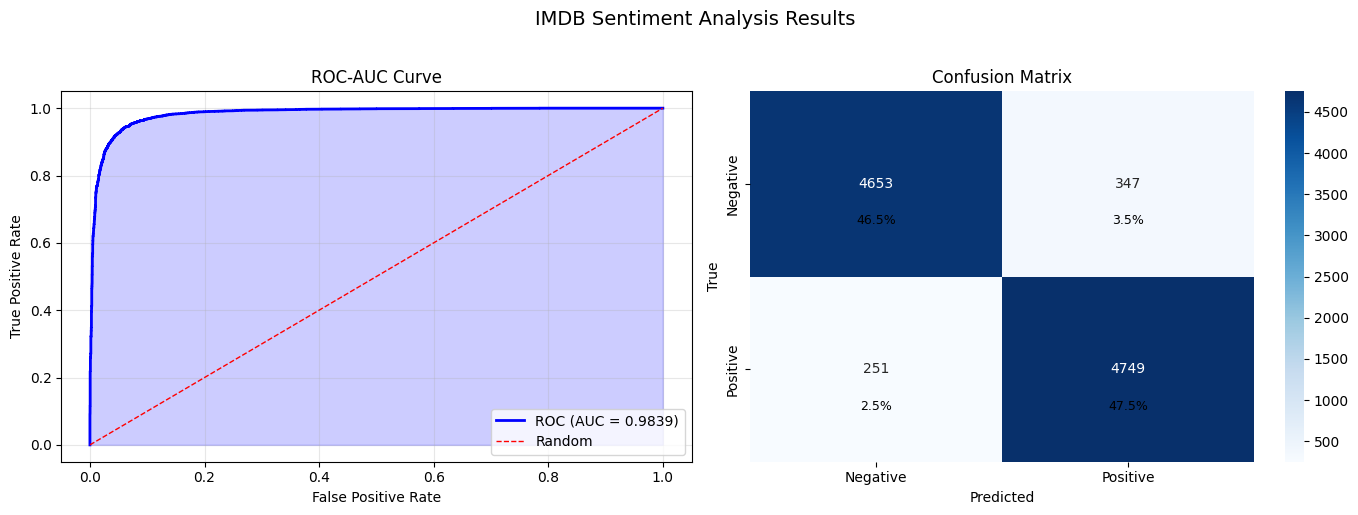

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_true, y_proba_pos)
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.2, color='blue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-AUC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix')

total = np.sum(cm)
for i in range(2):
    for j in range(2):
        axes[1].text(j+0.5, i+0.7, f'{cm[i, j]/total*100:.1f}%',
                    ha='center', va='center', color='black', fontsize=9)

plt.suptitle('IMDB Sentiment Analysis Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()